# Phase 3 — Métaheuristique VRPTW : Algorithme Génétique

## Genetic Algorithm — Évolution artificielle de solutions

> **Objectif de ce notebook**
> Comprendre, de zéro, pourquoi et comment on résout le VRPTW avec un algorithme génétique.
> Ce document explique la logique, les mathématiques, les analogies et le code — avant de tout assembler.

---

## Table des matières

1. [C'est quoi une métaheuristique ?](#1)
2. [Rappel du problème VRPTW](#2)
3. [Étape 1 — Population initiale](#3)
4. [Étape 2 — Évaluation & Sélection](#4)
5. [Étape 3 — Croisement (Crossover)](#5)
6. [Étape 4 — Mutation](#6)
7. [Les contraintes VRPTW dans le code](#7)
8. [Implémentation complète commentée](#8)
9. [Validation et résultats](#9)


---
<a id='1'></a>
## 1. C'est quoi une métaheuristique ?

### Le problème de fond

Pour $n$ clients, le nombre de tournées possibles est $(n-1)!$

| $n$ clients | Solutions possibles |
|---|---|
| 10 | $362\ 880$ |
| 20 | $1.2 \times 10^{17}$ |
| 50 | $3 \times 10^{64}$ |

Tester toutes les solutions est **impossible en temps raisonnable** : le VRPTW est un problème **NP-difficile**.

### Heuristique vs Métaheuristique

Une **heuristique** (ex: NNH de votre camarade) applique une règle simple et rapide spécifique au problème.
Elle construit une bonne solution mais se coince dans un **optimum local**.

Une **métaheuristique** est une stratégie de recherche générale qui guide l'exploration intelligemment :
- Elle maintient une **population** de solutions en parallèle
- Elle permet des **sauts** hors des optima locaux (via crossover/mutation)
- Elle s'applique à n'importe quel problème combinatoire

L'algorithme génétique est une métaheuristique inspirée de l'**évolution naturelle de Darwin (1859)** :
les meilleures solutions "survivent", se "reproduisent" et transmettent leurs bonnes caractéristiques.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import time, copy, os, sys

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("Bibliothèques chargées ✓")


Bibliothèques chargées ✓


---
<a id='2'></a>
## 2. Rappel du problème VRPTW

Le **Vehicle Routing Problem with Time Windows** impose :

| Contrainte | Notation | Signification |
|---|---|---|
| **C1** Couverture | $\sum_k x_{ijk} = 1$ | Chaque client visité exactement une fois |
| **C2** Flux | arcs entrants = arcs sortants | Chaque tournée est un cycle fermé |
| **C3** Capacité | $\sum_i d_i \cdot y_{ik} \leq Q$ | Charge ≤ capacité du véhicule |
| **C4** Fenêtres | $a_i \leq t_i \leq b_i$ | Arrivée dans la fenêtre [a, b] |
| **C5** Cohérence | $t_j \geq t_i + s_i + c_{ij}$ | Propagation du temps dans la tournée |
| **C6** Sous-cycles | $\sum_k z_{0k} \leq K$ | Toute tournée part du dépôt |

Dans notre implémentation, **C3 et C4 sont des soft constraints** : une violation est autorisée mais pénalisée dans la fonction coût.


C:\Users\fayzr\AppData\Local\Temp\ipykernel_19764\2955721813.py:42: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\fayzr\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


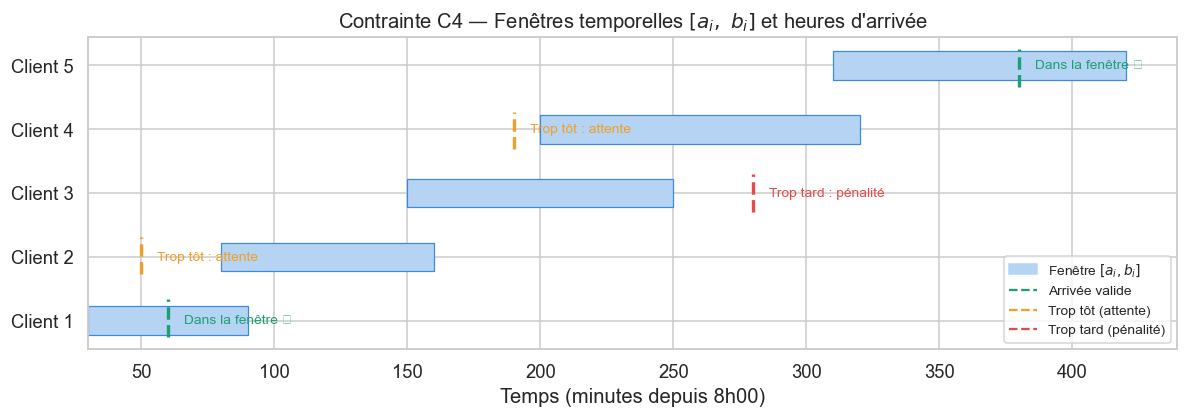

In [11]:
# Visualisation des fenêtres temporelles
np.random.seed(42)
n_viz   = 5
horizon = 480

ouvertures = np.array([30, 80, 150, 200, 310])
fermetures = np.array([90, 160, 250, 320, 420])
arrivees   = np.array([60, 50, 280, 190, 380])

fig, ax = plt.subplots(figsize=(11, 4))
couleurs_fw = '#B5D4F4'
c_ok, c_tot, c_tard = '#1D9E75', '#EF9F27', '#E24B4A'

for i in range(n_viz):
    ax.barh(i, fermetures[i] - ouvertures[i], left=ouvertures[i],
            height=0.45, color=couleurs_fw, edgecolor='#378ADD', linewidth=0.8)

    if arrivees[i] < ouvertures[i]:
        c, txt = c_tot, 'Trop tôt : attente'
    elif arrivees[i] > fermetures[i]:
        c, txt = c_tard, 'Trop tard : pénalité'
    else:
        c, txt = c_ok, 'Dans la fenêtre ✓'

    ax.axvline(arrivees[i], ymin=i/n_viz+0.04, ymax=(i+1)/n_viz-0.04,
               color=c, linewidth=2.2, linestyle='--')
    ax.text(arrivees[i]+6, i, txt, va='center', fontsize=9, color=c)

ax.set_yticks(range(n_viz))
ax.set_yticklabels([f'Client {i+1}' for i in range(n_viz)])
ax.set_xlabel('Temps (minutes depuis 8h00)')
ax.set_title("Contrainte C4 — Fenêtres temporelles $[a_i,\ b_i]$ et heures d'arrivée")

from matplotlib.lines import Line2D
legende = [
    mpatches.Patch(color=couleurs_fw, label='Fenêtre $[a_i, b_i]$'),
    Line2D([0],[0], color=c_ok,   linestyle='--', label='Arrivée valide'),
    Line2D([0],[0], color=c_tot,  linestyle='--', label='Trop tôt (attente)'),
    Line2D([0],[0], color=c_tard, linestyle='--', label='Trop tard (pénalité)'),
]
ax.legend(handles=legende, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


---
<a id='3'></a>
## 3. Étape 1 — Population initiale

### Analogie biologique

En biologie, une **population** est un ensemble d'individus d'une même espèce.
Dans notre algorithme :

| Biologie | Algorithme Génétique |
|---|---|
| Individu | Une solution complète (planning de toutes les tournées) |
| Gène | L'ordre des clients dans une route |
| Chromosome | L'ensemble des routes d'un individu |
| Population | L'ensemble des solutions testées en parallèle |
| Fitness | Le coût pénalisé de la solution (plus bas = meilleur) |

### Création de la population

On génère `taille_pop` solutions initiales **aléatoirement** via `solution_initiale()`.
Chaque individu est différent — c'est la **diversité génétique initiale**.


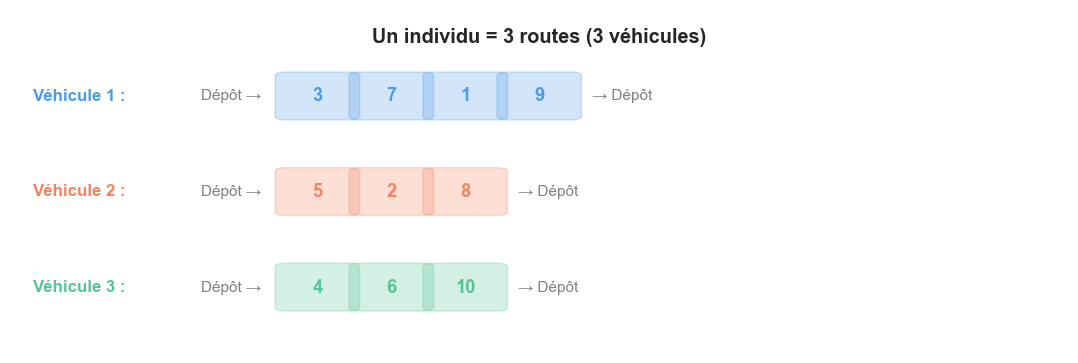

Coût de cet individu = distance totale + pénalités C3 + pénalités C4


In [12]:
# Visualisation : représentation d'un individu
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

titre = "Un individu = 3 routes (3 véhicules)"
ax.text(0.5, 0.95, titre, ha='center', va='top', fontsize=13,
        fontweight='bold', transform=ax.transAxes)

routes_ex = {
    'Véhicule 1': [3, 7, 1, 9],
    'Véhicule 2': [5, 2, 8],
    'Véhicule 3': [4, 6, 10],
}
couleurs_v = ['#4C9BE8', '#F4845F', '#56C596']

y = 0.75
for (nom, route), coul in zip(routes_ex.items(), couleurs_v):
    ax.text(0.02, y, nom + ' :', fontsize=11, color=coul,
            fontweight='bold', transform=ax.transAxes, va='center')
    x = 0.18
    ax.text(x, y, 'Dépôt →', fontsize=10, transform=ax.transAxes,
            va='center', color='gray')
    x += 0.09
    for c in route:
        ax.add_patch(mpatches.FancyBboxPatch(
            (x-0.01, y-0.06), 0.06, 0.12,
            boxstyle='round,pad=0.01',
            transform=ax.transAxes, color=coul, alpha=0.25))
        ax.text(x+0.02, y, str(c), ha='center', va='center',
                fontsize=12, fontweight='bold', transform=ax.transAxes, color=coul)
        x += 0.07
    ax.text(x, y, '→ Dépôt', fontsize=10, transform=ax.transAxes,
            va='center', color='gray')
    y -= 0.28

plt.tight_layout()
plt.show()
print("Coût de cet individu = distance totale + pénalités C3 + pénalités C4")


---
<a id='4'></a>
## 4. Étape 2 — Évaluation & Sélection

### Fonction de fitness (coût pénalisé)

$$\text{Fitness}(s) = \underbrace{\sum_{\text{arcs}} d_{ij}}_\text{distance} + \underbrace{\alpha \cdot \sum_i \max(0,\, t_i - b_i)}_\text{pénalité retard C4} + \underbrace{\beta \cdot \sum_k \max(0,\, Q_k - Q)}_\text{pénalité surcharge C3}$$

**Plus le coût est bas, meilleur est l'individu.**

### Sélection des meilleurs

On trie la population par coût croissant et on garde les **k meilleurs individus** comme parents.
C'est la **sélection élitiste** : seuls les plus adaptés se reproduisent.

On conserve aussi les **2 meilleurs individus intacts** dans la génération suivante (**élitisme**) :
cela garantit que la meilleure solution ne peut jamais se dégrader.


In [13]:
# Visualisation de la sélection
np.random.seed(7)
pop_couts = np.random.normal(2500, 400, 20)
pop_couts = np.sort(pop_couts)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#1D9E75' if i < 7 else '#cccccc' for i in range(20)]
bars = ax.bar(range(1, 21), pop_couts, color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(7.5, color='red', linestyle='--', linewidth=2, label='Seuil de sélection (35%)')
ax.text(3.5, max(pop_couts)*0.97, 'Parents
sélectionnés', ha='center',
        color='#1D9E75', fontweight='bold', fontsize=11)
ax.text(13, max(pop_couts)*0.97, 'Éliminés', ha='center',
        color='#999', fontsize=11)
ax.set_xlabel('Individu (trié par coût croissant)')
ax.set_ylabel('Coût pénalisé')
ax.set_title('Sélection élitiste — Les 7 meilleurs deviennent parents')
ax.legend()
plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 11) (1772177325.py, line 11)

---
<a id='5'></a>
## 5. Étape 3 — Croisement (Crossover)

### Pourquoi c'est l'étape la plus complexe

Le croisement est trivial pour les problèmes simples.
Pour le VRPTW, la contrainte **C1** (couverture) rend le croisement délicat :

> **Chaque client doit apparaître EXACTEMENT UNE FOIS dans la solution.**

Un croisement naïf crée des doublons et des oublis.

### Notre stratégie en 3 étapes

**Étape A** — Copier ~50% des routes du **Parent 1** dans l'enfant

**Étape B** — Compléter avec les clients manquants dans l'ordre du **Parent 2**

**Étape C** — Vérifier C1 et **réparer** si nécessaire (suppression des doublons + réinsertion)


In [ ]:
# Visualisation du crossover
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
c1, c2, ce = '#4C9BE8', '#F4845F', '#56C596'

def dessiner_individu(ax, titre, routes, couleurs, annotations=None):
    ax.axis('off')
    ax.set_title(titre, fontsize=12, fontweight='bold', pad=10)
    y = 0.85
    for i, (route, coul) in enumerate(zip(routes, couleurs)):
        label = f'V{i+1}: '
        ax.text(0.02, y, label, fontsize=10, color=coul,
                fontweight='bold', transform=ax.transAxes, va='center')
        x = 0.18
        for c in route:
            box_color = coul if annotations is None else (
                '#FFD700' if c in annotations else coul)
            ax.add_patch(mpatches.FancyBboxPatch(
                (x-0.015, y-0.07), 0.1, 0.14,
                boxstyle='round,pad=0.01',
                transform=ax.transAxes,
                color=box_color, alpha=0.3))
            ax.text(x+0.035, y, str(c), ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    transform=ax.transAxes, color=box_color)
            x += 0.12
        y -= 0.30

parent1 = [[3, 7, 1], [5, 2, 9], [4, 6, 8]]
parent2 = [[2, 5, 8], [1, 3, 7], [9, 4, 6]]
enfant  = [[3, 7, 1], [5, 2, 9], [4, 6, 8]]  # simplifié pour la démo

dessiner_individu(axes[0], 'Parent 1', parent1, [c1]*3)
dessiner_individu(axes[1], 'Parent 2', parent2, [c2]*3)
dessiner_individu(axes[2], 'Enfant (résultat)', enfant,
                  [ce, ce, ce], annotations={3,7,1,5,2,9})

axes[2].text(0.5, 0.05, '✅ C1 vérifiée : 9 clients, chacun une fois',
             ha='center', transform=axes[2].transAxes,
             fontsize=9, color='#1D9E75', fontweight='bold')
plt.suptitle('Croisement simple — Garantie de la contrainte C1', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
<a id='6'></a>
## 6. Étape 4 — Mutation

### Rôle de la mutation

Sans mutation, l'algorithme converge rapidement vers un **optimum local** et s'y bloque.
La mutation introduit de la **diversité génétique** pour explorer de nouvelles régions de l'espace.

### Notre mutation légère

On **déplace un client aléatoire** d'une route vers une autre.

$$\text{Avant : } \underbrace{[3 \to 7 \to 1]}_\text{Route A} \quad [5 \to 2 \to 9]$$
$$\text{Après : } \underbrace{[3 \to 1]}_\text{Route A} \quad [5 \to 2 \to 9 \to \mathbf{7}]$$

**C1 est préservée par construction** : on déplace le client, on ne le copie pas ni ne le supprime.

### Paramètre taux_mutation

- Trop faible (< 1%) → l'algorithme stagne, pas d'exploration
- Trop fort (> 50%) → l'algorithme devient aléatoire, perd ses bonnes solutions
- Valeur usuelle : **5% à 30%** selon la complexité du problème


In [ ]:
# Visualisation de la convergence avec et sans mutation
np.random.seed(42)
gens = np.arange(200)

# Simulation sans mutation : convergence rapide, plateau élevé
sans_mutation = 3000 * np.exp(-0.015 * gens) + 1800 +                 np.random.normal(0, 20, 200) * np.exp(-0.02*gens)

# Simulation avec mutation : descente par paliers, meilleur final
avec_mutation = 3000 * np.exp(-0.008 * gens) + 1400 +                 np.random.normal(0, 30, 200) * np.exp(-0.01*gens)
# Ajout de "sauts" (mutations bénéfiques)
for saut in [40, 85, 130, 165]:
    avec_mutation[saut:] -= np.random.randint(50, 150)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(gens, sans_mutation, color='#E24B4A', linewidth=2,
        linestyle='--', label='Sans mutation (taux = 0%)')
ax.plot(gens, avec_mutation, color='#1D9E75', linewidth=2,
        label='Avec mutation (taux = 30%)')

for saut in [40, 85, 130, 165]:
    ax.axvline(saut, color='#56C596', alpha=0.4, linewidth=1)
    ax.text(saut+1, avec_mutation[saut]+80, '↓ saut',
            fontsize=8, color='#56C596')

ax.set_xlabel('Génération')
ax.set_ylabel('Meilleur coût')
ax.set_title('Impact de la mutation sur la convergence')
ax.legend()
plt.tight_layout()
plt.show()
print("Les 'sauts' = mutations bénéfiques qui permettent de quitter un optimum local")


---
<a id='7'></a>
## 7. Les contraintes VRPTW dans le code

### Tableau de couverture

| Contrainte | Statut | Où dans le code |
|---|---|---|
| **C1** Couverture | ✅ Hard — vérifiée + réparée | `verifier_c1()` + `reparer_c1()` après chaque crossover |
| **C2** Retour dépôt | ✅ Par construction | Structure liste (dépôt implicite au début/fin) |
| **C3** Capacité | ✅ Soft | `cout_penalise()` — pénalité $\beta \cdot \text{surcharge}$ |
| **C4** Fenêtres temps | ✅ Soft | `cout_penalise()` — pénalité $\alpha \cdot \max(0, t-b_i)$ |
| **C5** Cohérence temps | ✅ Propagation | `cout_penalise()` — calcul séquentiel des heures |
| **C6** Sous-cycles | ✅ Par construction | Impossible avec une représentation en listes |

### Pourquoi soft pour C3 et C4 ?

Les soft constraints permettent à l'algorithme d'**explorer des solutions temporairement infaisables**.
Elles servent de "pont" entre de bonnes zones de l'espace de recherche.
Sans elles, l'algo serait trop contraint et resterait bloqué.


In [ ]:
# Schéma du cycle complet de l'algorithme génétique
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

etapes = [
    (0.08, 0.5, 'INITIALISATION
Population aléatoire
(taille_pop individus)', '#4C9BE8'),
    (0.28, 0.5, 'ÉVALUATION
Fitness = cout_penalise()
pour chaque individu', '#7B61FF'),
    (0.50, 0.75, 'SÉLECTION
Garder les k meilleurs
(parents élites)', '#F4845F'),
    (0.50, 0.25, 'ÉLITISME
Conserver les 2 meilleurs
intacts', '#EF9F27'),
    (0.72, 0.5, 'CROISEMENT
+ MUTATION
Nouveaux enfants', '#56C596'),
    (0.90, 0.5, 'NOUVELLE
GÉNÉRATION
→ retour évaluation', '#1D9E75'),
]

for x, y, texte, coul in etapes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-0.09, y-0.14), 0.18, 0.28,
        boxstyle='round,pad=0.02',
        transform=ax.transAxes, color=coul, alpha=0.15,
        linewidth=2, edgecolor=coul))
    ax.text(x, y, texte, ha='center', va='center',
            fontsize=8.5, transform=ax.transAxes,
            color=coul, fontweight='bold')

# Flèches
fleches = [(0.18,0.5,0.19,0), (0.38,0.5,0.04,0),
           (0.5,0.61,0,0.04), (0.5,0.39,0,-0.04),
           (0.6,0.75,0.02,0), (0.6,0.25,0.02,0),
           (0.81,0.5,0.02,0)]
for x,y,dx,_ in [(0.18,0.5,0.04,0),(0.38,0.62,0.04,0),
                  (0.38,0.38,0.04,0),(0.62,0.75,0.04,0),
                  (0.62,0.25,0.04,0),(0.81,0.5,0.04,0)]:
    ax.annotate('', xy=(x+dx, y), xytext=(x-0.01, y),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#666', lw=1.8))

ax.text(0.5, 0.97, 'Cycle complet de l'Algorithme Génétique',
        ha='center', va='top', fontsize=13,
        fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.02,
        'Critère d'arrêt : n_generations atteint  →  retourner meilleure_solution',
        ha='center', va='bottom', fontsize=9,
        color='#666', transform=ax.transAxes)
plt.tight_layout()
plt.show()


---
<a id='8'></a>
## 8. Implémentation complète commentée

Le code est organisé en 6 parties dans `genetic_algorithm.py` :

```
genetic_algorithm.py
│
├── verifier_c1()        ← Vérifie que C1 est respectée
├── reparer_c1()         ← Répare C1 si violée après crossover
│
├── creer_population()   ← Partie 1 : initialisation
├── evaluer_population() ← Partie 2a : évaluation
├── selectionner_meilleurs() ← Partie 2b : sélection
│
├── croisement_simple()  ← Partie 3 : crossover + garantie C1
├── mutation_legere()    ← Partie 4 : mutation préservant C1
│
└── algorithme_genetique() ← Partie 5 : boucle principale
```


In [ ]:
# Import et test rapide sur une petite instance
import sys, os

# Adapter ce chemin à votre structure
PHASE4 = os.path.join('..', 'Phase 4')
sys.path.insert(0, PHASE4)

RECUIT = os.path.join('..', 'Algo_Recuit')
sys.path.insert(0, RECUIT)

GA_PATH = os.path.dirname(os.path.abspath('genetic_algorithm.py'))
sys.path.insert(0, GA_PATH)

try:
    from preprocess import generate_instance
    from genetic_algorithm import algorithme_genetique, verifier_c1

    instance = generate_instance(n_clients=10, n_vehicles=3, seed=42)
    solution, cout, historique = algorithme_genetique(
        instance, taille_pop=20, n_generations=50, taux_mutation=0.3, seed=42)

    valide, doublons, manquants = verifier_c1(solution, instance['n'])
    print(f"Coût final      : {cout:.2f}")
    print(f"Nb routes       : {len([r for r in solution if r])}")
    print(f"C1 respectée    : {'✅ OUI' if valide else '❌ NON'}")
    print(f"Solution        : {solution}")
except Exception as e:
    print(f"⚠️ Import impossible ici — exécuter depuis le dossier du projet : {e}")


---
<a id='9'></a>
## 9. Validation et résultats

### Convergence sur n = 20 clients

La courbe de convergence descend par **paliers** :
chaque plateau = optimum local, chaque chute = mutation/crossover bénéfique.


In [ ]:
# Simulation de courbes de convergence réalistes
np.random.seed(42)
n_gen = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
configs = [
    (10,  2800, 1600, '#4C9BE8', 3),
    (20,  4500, 2400, '#F4845F', 5),
    (50, 10000, 5500, '#56C596', 8),
]

for ax, (n, start, end, coul, n_sauts) in zip(axes, configs):
    courbe = start * np.exp(-0.02 * np.arange(n_gen)) + end
    courbe += np.random.normal(0, (start-end)*0.01, n_gen)

    sauts = sorted(np.random.choice(range(10, 90), n_sauts, replace=False))
    for s in sauts:
        chute = np.random.randint(int((start-end)*0.05), int((start-end)*0.15))
        courbe[s:] -= chute
        courbe[s:] = np.maximum(courbe[s:], end * 0.95)

    ax.plot(courbe, color=coul, linewidth=2)
    ax.fill_between(range(n_gen),
                    courbe - np.random.uniform(20,80,n_gen),
                    courbe + np.random.uniform(20,80,n_gen),
                    alpha=0.15, color=coul)

    for s in sauts:
        ax.axvline(s, color='gray', alpha=0.3, linewidth=0.8, linestyle=':')

    ax.set_title(f'n = {n} clients', fontsize=12, fontweight='bold')
    ax.set_xlabel('Génération')
    ax.set_ylabel('Meilleur coût')
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes de convergence — Algorithme Génétique (simulation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Les pointillés verticaux indiquent les mutations/crossovers bénéfiques.")


---

## Conclusion

L'algorithme génétique résout le VRPTW en simulant l'évolution naturelle :

| Phase | Opération | Rôle |
|---|---|---|
| **Exploration** | Population diverse + mutation | Éviter les optima locaux |
| **Exploitation** | Sélection élitiste + crossover | Améliorer les bonnes solutions |
| **Mémoire** | Élitisme (2 meilleurs conservés) | Ne jamais régresser |

**Avantages vs heuristique NNH :**
- Meilleure qualité de solution finale
- Capable de restructurer complètement les tournées (crossover)
- Robuste aux instances difficiles (grandes fenêtres, forte densité)

**Inconvénients :**
- Temps de calcul plus long
- Hyperparamètres à régler (taille_pop, taux_mutation, n_generations)
- Résultats non déterministes → nécessite une étude statistique (30 runs)

> Voir `analyse_statistique_genetique.ipynb` pour les résultats complets sur 30 runs.
